# Genetic Algorithm Tuning
This notebook tunes the genetic algorithm and checks the operators are valid and working as expected.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pickle

In [3]:
def extract_results(path):
    full_path = f"outputs/{path}.pkl"
    with open(full_path, "rb") as f:
        results = pickle.load(f)
    
    return results['solutions'], results['evolution_stats'], results['timings']

## **Parent Selection**
These checks below are to understand if there are any issues with using tournament selection for the genetic algorithm.

In [4]:
from utils.plots import (
    plot_parent_selection_stats,
    plot_survivor_selection,
    plot_covergence,
    plot_fitness_vs_time
)

In [33]:
solution_grid, stats_grid, time_grid = extract_results('grid_city_20_experiments_analysis')
# solution_moderate, stats_moderate, time_moderate = extract_results('moderate_city_20_experiments_analysis')
solution_bottleneck, stats_bottleneck, time_bottleneck = extract_results('bottleneck_city_20_experiments_analysis')

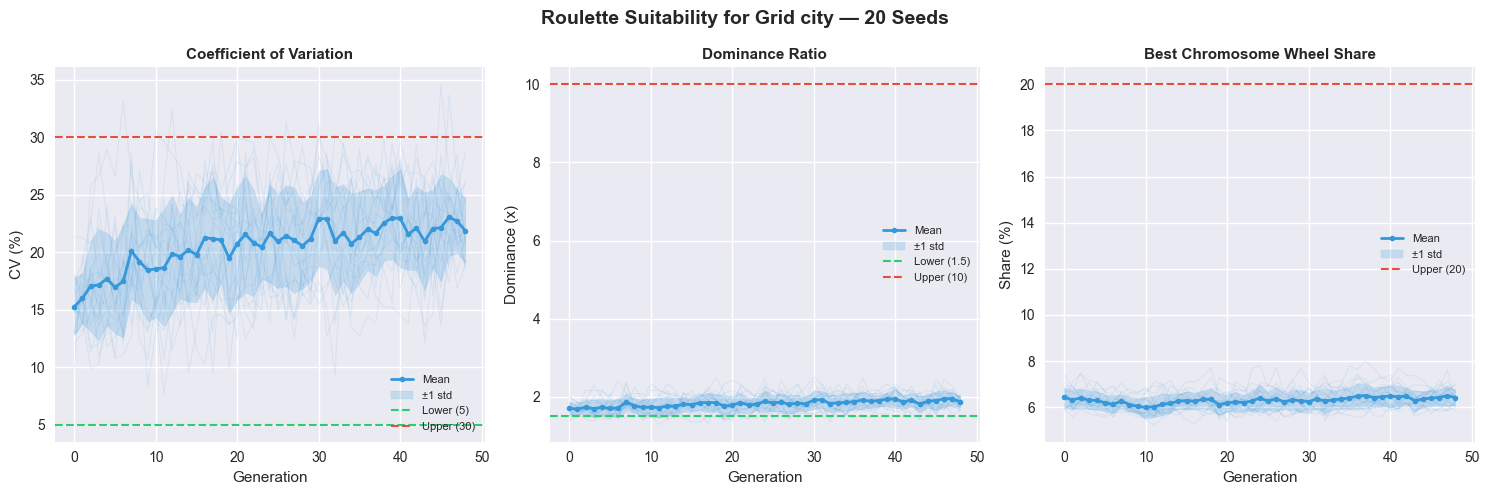

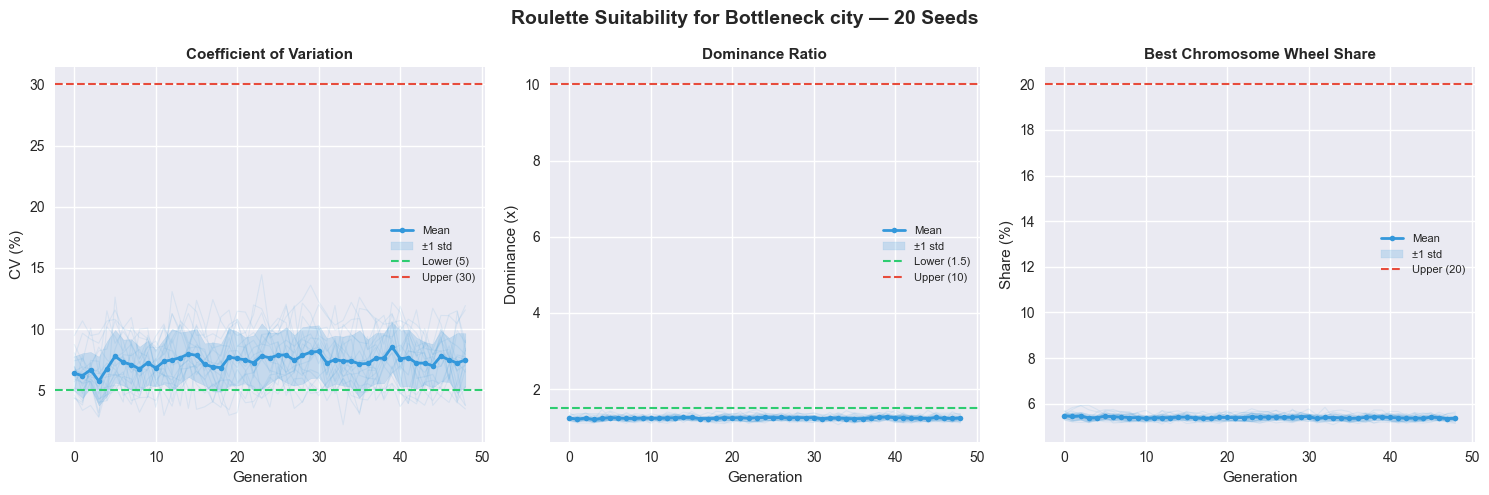

In [34]:
plot_parent_selection_stats(evolution_stats=stats_grid, city_name='grid_city')
# plot_parent_selection_stats(evolution_stats=stats_moderate, city_name='moderate_city')
plot_parent_selection_stats(evolution_stats=stats_bottleneck, city_name='bottleneck_city')


#### **Coefficient of Variance**
Checks the value of the `std/mean`. If this value is too small (<5%) then the fitness values are too similar and then if this is too large (>30%) then one solution might be dominating the solution.

**Results**
* Grid City - the mean values sit consistently around 15 which is within the 5-30% range. There is a range of varaince across the seeds as well which means roulette selection has meaningful selection, however some of the evolutions do exceed the upper limit.
* The moderate city shows similar patterns to the grid city but the cv value lower than the grid which makes sense as there should be less route options compared the the grid city.
* The bottleneck city has a much lower cv value, however it sits right above theshold line which is just about ok. 

#### **Dominance**
Checks the value of `max/min` for the fitness value. If the value is too small (<1.5) then the results are too similar and if the value is too large (>10) the best solution is significantly better than the worse.

**Results**
* Grid City - the mean value for this metric sits just above the 1.5 multiplier threshold.
* Moderate City - simialr to the grid city the value sits just above the threshold line.
* Bottleneck City - for the bottleneck city the value sits under the threshold line which confirms the population is too similar — roulette has almost no meaningful selection pressure in Bottleneck City.

#### **Best Share**
This value also checks how much the best chromosome makes up of the wheel, `max/total` for the inverse fitness value.

**Results**
* Grid City - the mean value sits around 6% which is well below the 20% meaning the best chromosome never dominates the roulette wheel, meaning the weaker solutions get a chance to be selected.
* Moderate city - similar to the grid city the mean value sits around 6-7% meaning it doesn't dominate the roulette wheel.
* Bottleneck city - the value sits around 5-6%.


#### **Tournament Selection**

In [7]:
_, stats_grid_tournament, _ = extract_results('grid_city_20_experiments_analysis_tournament')
_, stats_moderate_tournament, _ = extract_results('moderate_city_20_experiments_analysis_tournament')
_, stats_bottleneck_tournament, _ = extract_results('bottleneck_city_20_experiments_analysis_tournament')


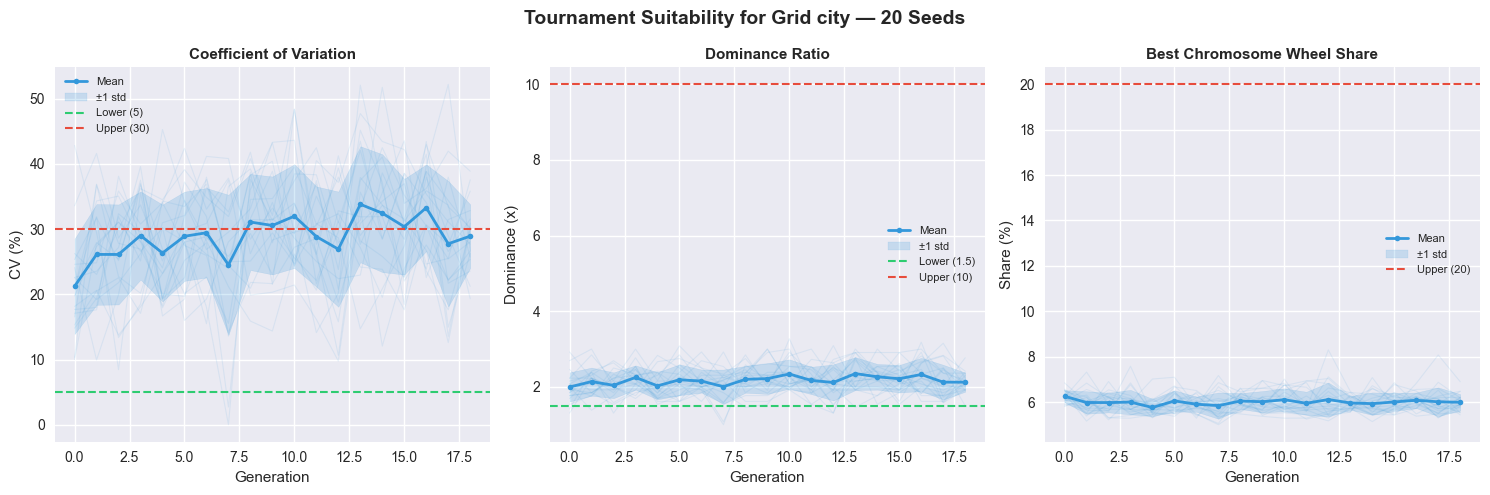

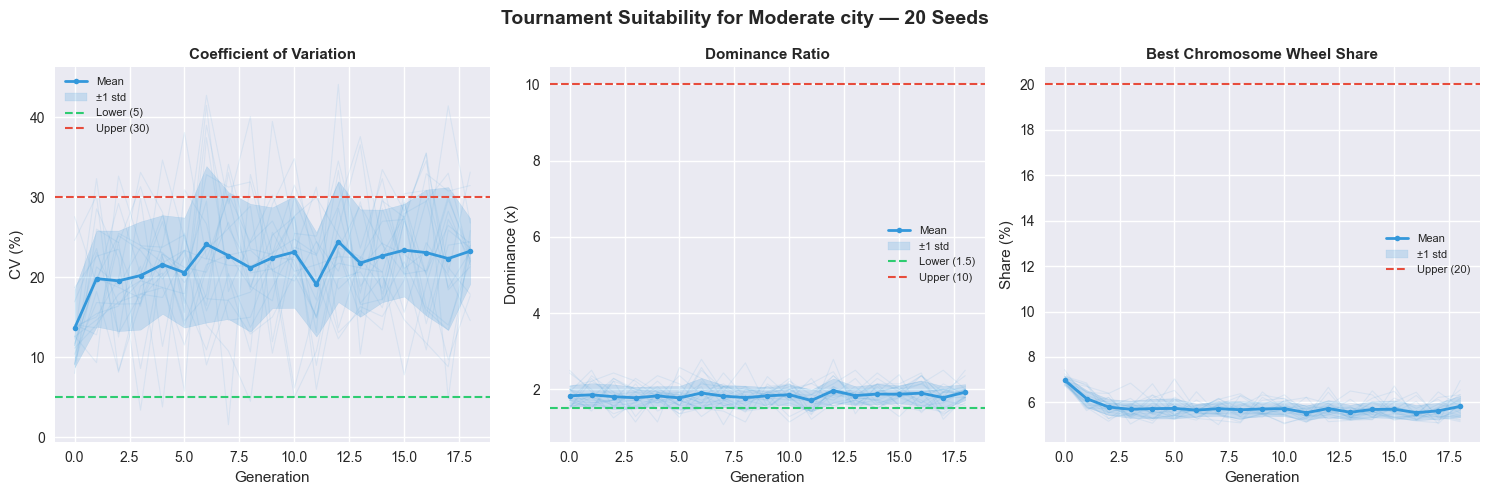

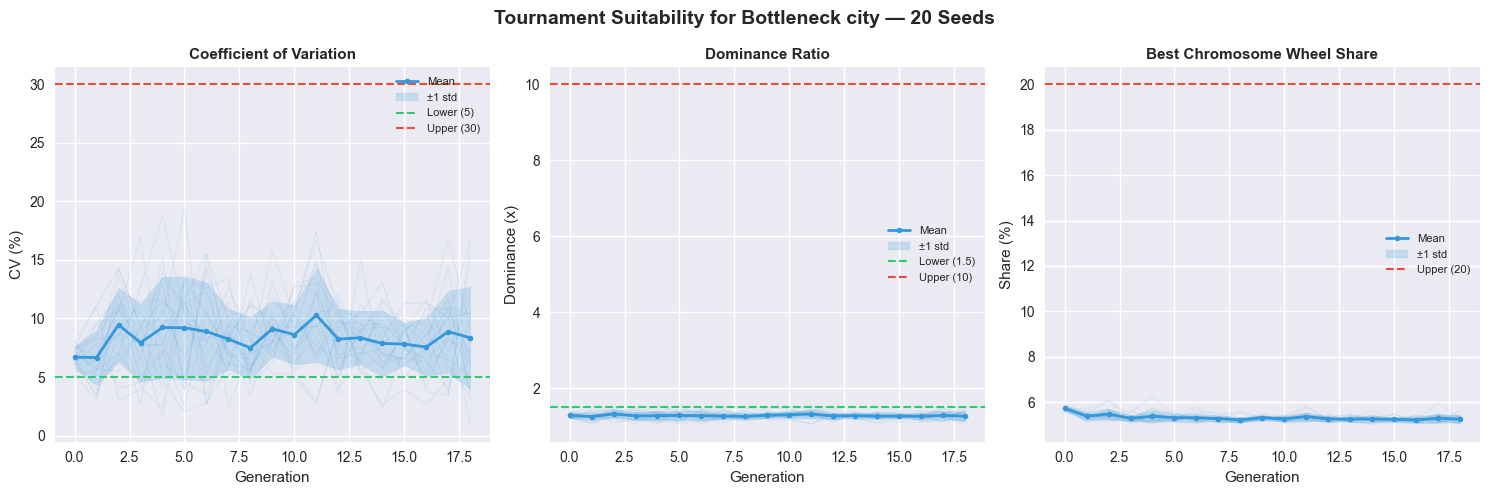

In [8]:
plot_parent_selection_stats(evolution_stats=stats_grid_tournament, city_name='grid_city', method='Tournament')
plot_parent_selection_stats(evolution_stats=stats_moderate_tournament, city_name='moderate_city', method='Tournament')
plot_parent_selection_stats(evolution_stats=stats_bottleneck_tournament, city_name='bottleneck_city', method='Tournament')

`Conclusion`
It's A Tuning Problem Not A Selection Problem
* Tournament doesn't fix Bottleneck City's low dominance — it actually makes it worse (1.4x → 1.2x)
* Tournament increases variance in Grid City CV — some seeds breach the 30% upper threshold
* Bottleneck City's low dominance and CV is consistent across both selection methods

This means the problem is not how parents are selected but rather that Bottleneck City's constrained solution space produces inherently similar chromosomes.

## **Survivor Selection**
* Plot the proportion of parents vs children when using elite selection.
* Compare the best score across parent and child to see if there's any improvement.
* Compare the number of passthrough parents - this might also need looking at in the hyperparameters later.
* Try both approaches with large number of evolutions - does the child approach reach the same result but just with more evolutions?

### Grid City Survivor Selection Methods

In [ ]:
# solution_grid_elite_perc, stats_grid_elite_perc, time_grid_elite_perc = extract_results('grid_city_20_survivor_selection_elite_percentage_experiments_analysis')
solution_grid_elite, stats_grid_elite, time_grid_elite = extract_results('grid_city_20_survivor_selection_elite_experiments_analysis')
solution_grid_child, stats_grid_child, time_grid_child = extract_results('grid_city_20_survivor_selection_children_experiments_analysis')

### Moderate City Survivor Selection

In [ ]:
# solution_moderate_elite_perc, stats_moderate_elite_perc, time_moderate_elite_perc = extract_results('moderate_city_20_survivor_selection_elite_percentage_experiments_analysis')
solution_moderate_elite, stats_moderate_elite, time_moderate_elite = extract_results('moderate_city_20_survivor_selection_elite_experiments_analysis')
solution_moderate_child, stats_moderate_child, time_moderate_child = extract_results('moderate_city_20_survivor_selection_children_experiments_analysis')


### Bottleneck City Survivor Selection

In [ ]:
# solution_bottleneck_elite_perc, stats_bottleneck_elite_perc, time_bottleneck_elite_perc = extract_results('bottleneck_city_20_survivor_selection_elite_percentage_experiments_analysis')
solution_bottleneck_elite, stats_bottleneck_elite, time_bottleneck_elite = extract_results('bottleneck_city_20_survivor_selection_elite_experiments_analysis')
solution_bottleneck_child, stats_bottleneck_child, time_bottleneck_child = extract_results('bottleneck_city_20_survivor_selection_children_experiments_analysis')


### Results

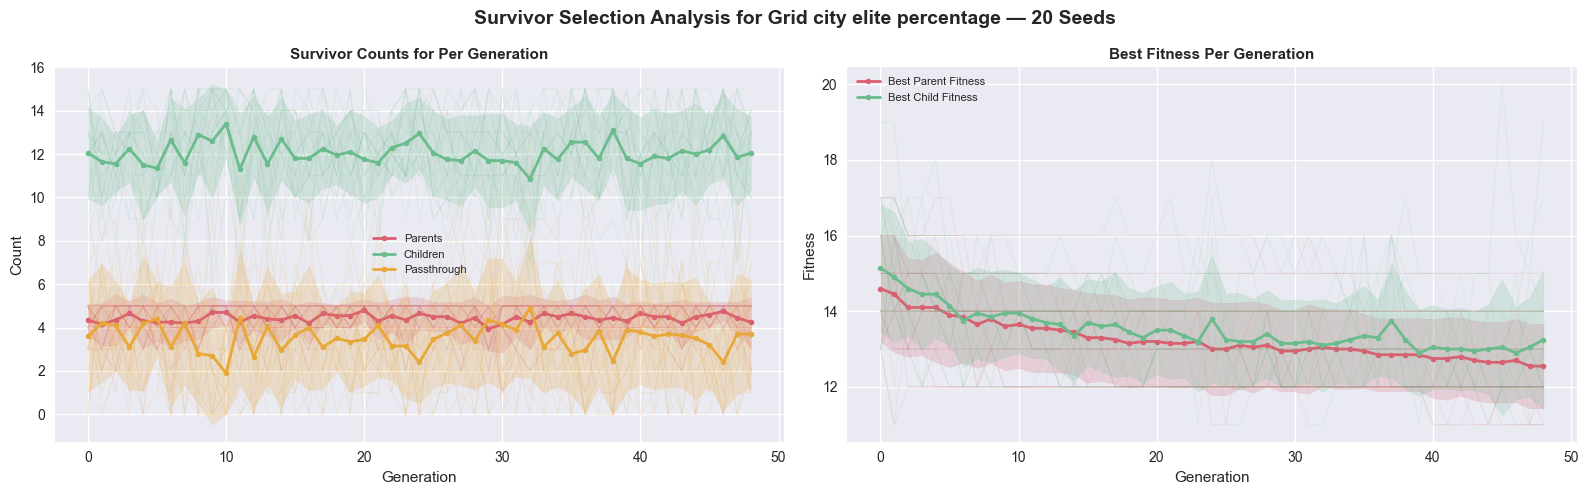

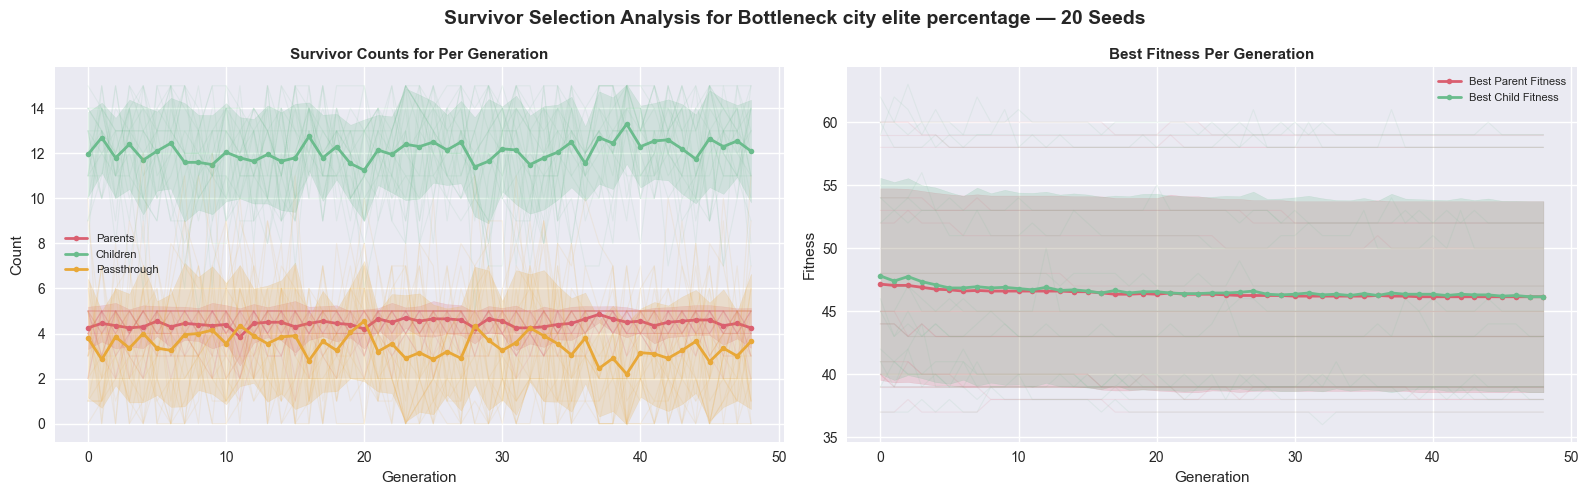

In [35]:
plot_survivor_selection(stats_grid, 'grid_city_elite_percentage')
# plot_survivor_selection(stats_moderate, 'moderate_city_elite_percentage')
plot_survivor_selection(stats_bottleneck, 'bottleneck_city_elite_percentage')


`Conclusion`
For the elite percentage the fitness functions are decreasing over time however not significantly. This could be due to the limited number of parents going through the process (approx 1). This might mean we need to do further experiments to increase the percentage of parents brought through.

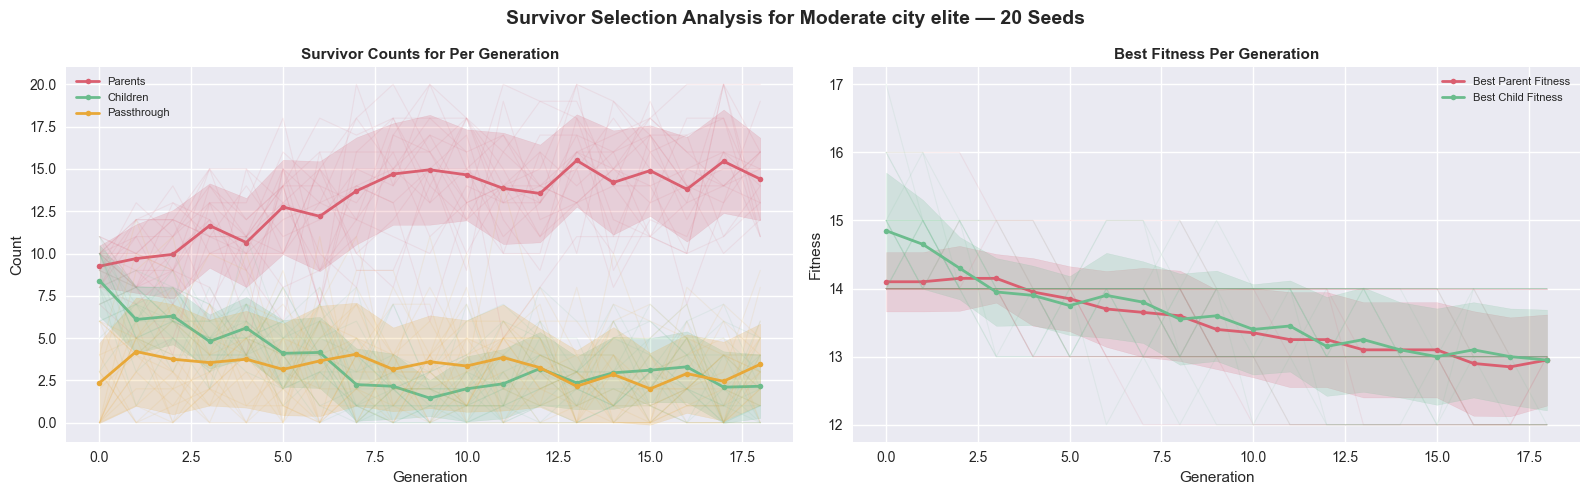

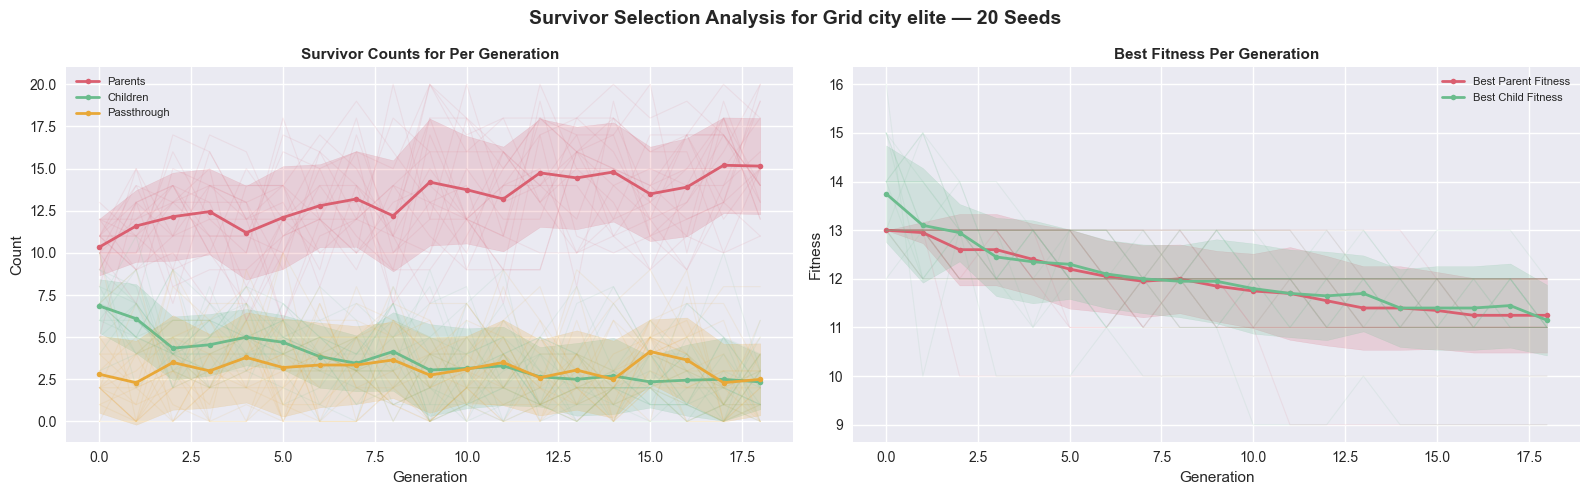

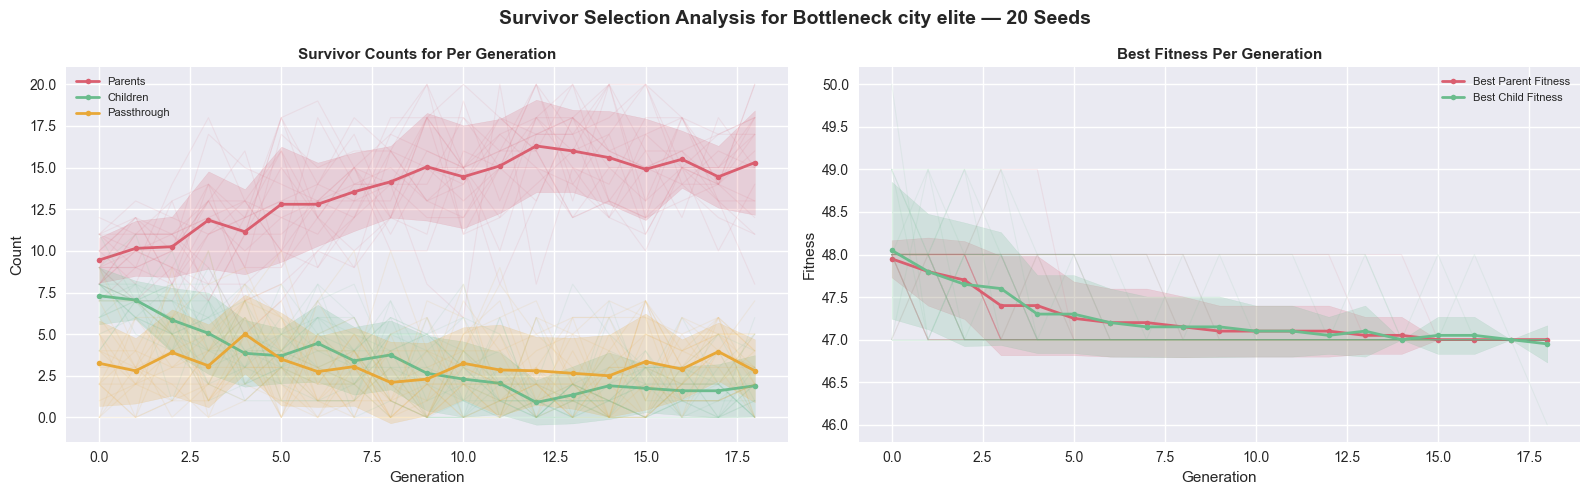

In [13]:
plot_survivor_selection(stats_moderate_elite, 'moderate_city_elite')
plot_survivor_selection(stats_grid_elite, 'grid_city_elite')
plot_survivor_selection(stats_bottleneck_elite, 'bottleneck_city_elite')


`Conclusion`
For the elite approach, we can see the fitness function decreasing over time (more than the percentage approach). The number of parents kept over the evolutions increased, with the number of children decreasing over time as the population matures.

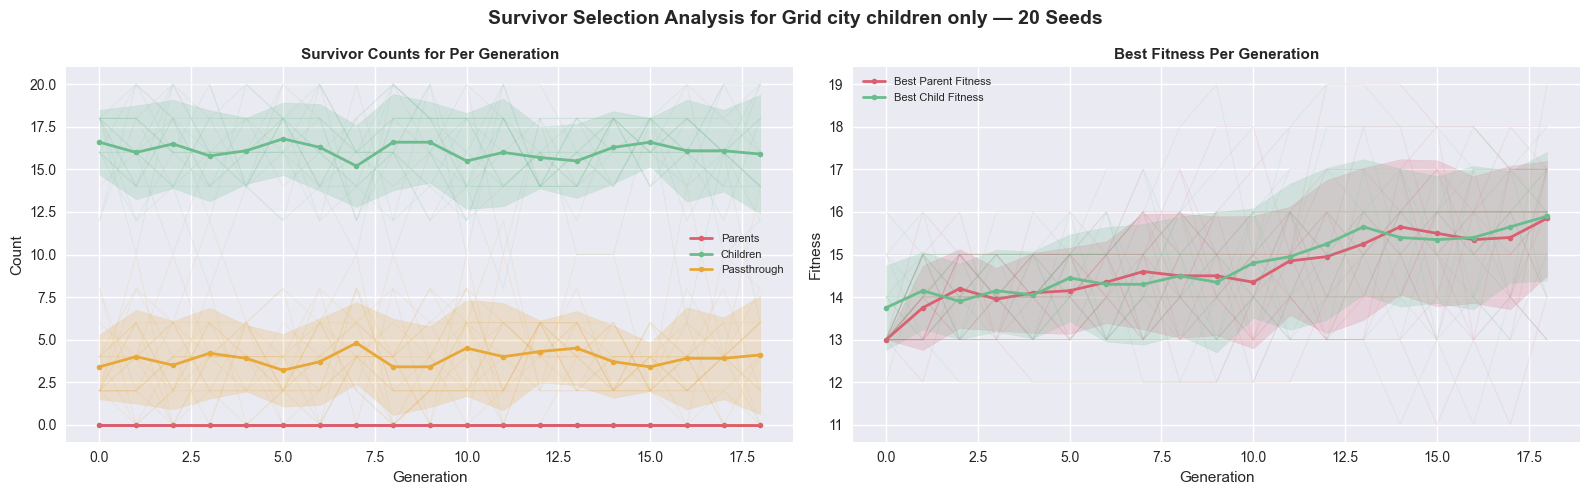

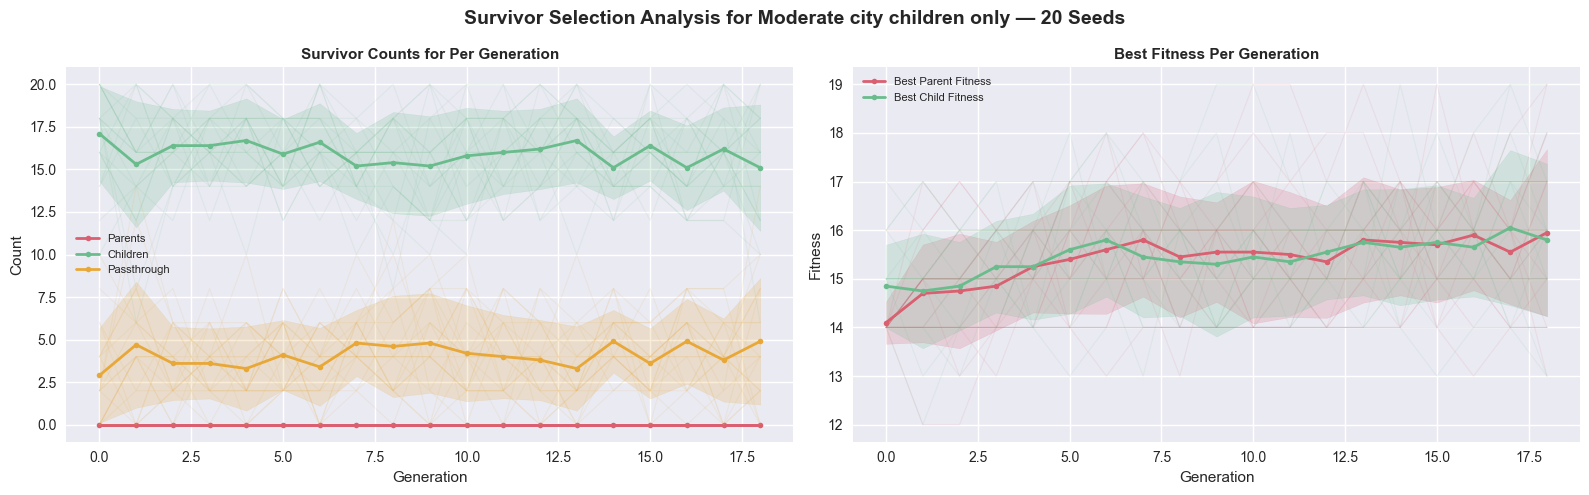

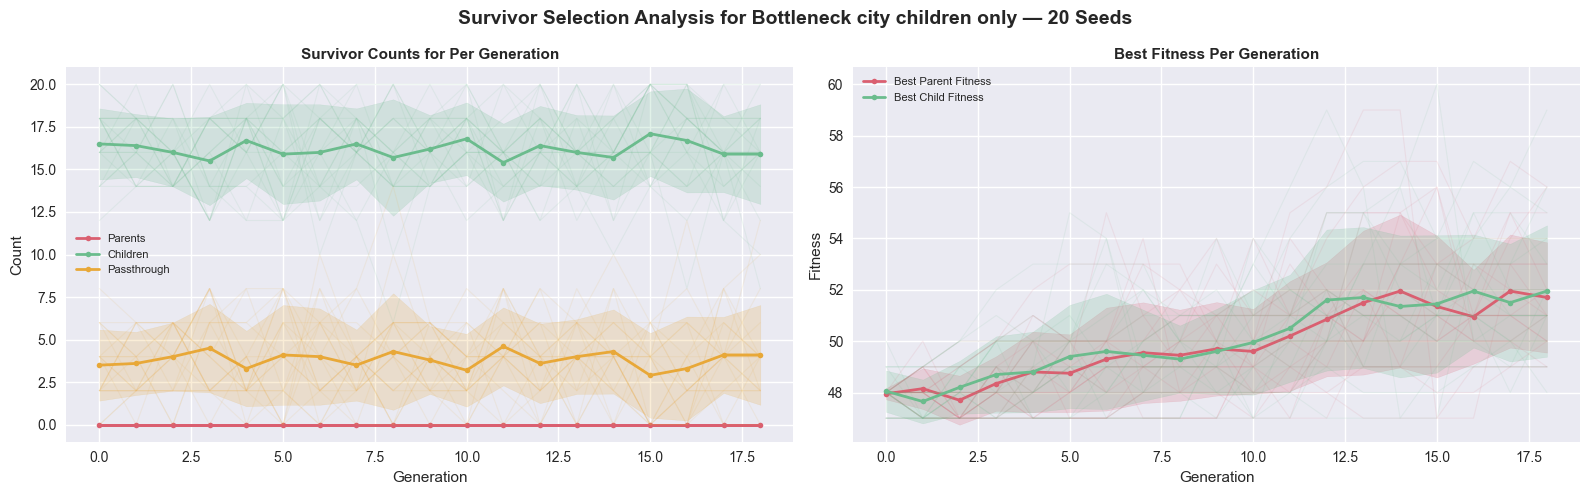

In [14]:
plot_survivor_selection(stats_grid_child, 'grid_city_children_only')
plot_survivor_selection(stats_moderate_child, 'moderate_city_children_only')
plot_survivor_selection(stats_bottleneck_child, 'bottleneck_city_children_only')


`Conclusion`
For the children only selection method the fitness function (left) is increasing over the generations which means the algorithnm is getting worse over time.

#### Tournament Selection 

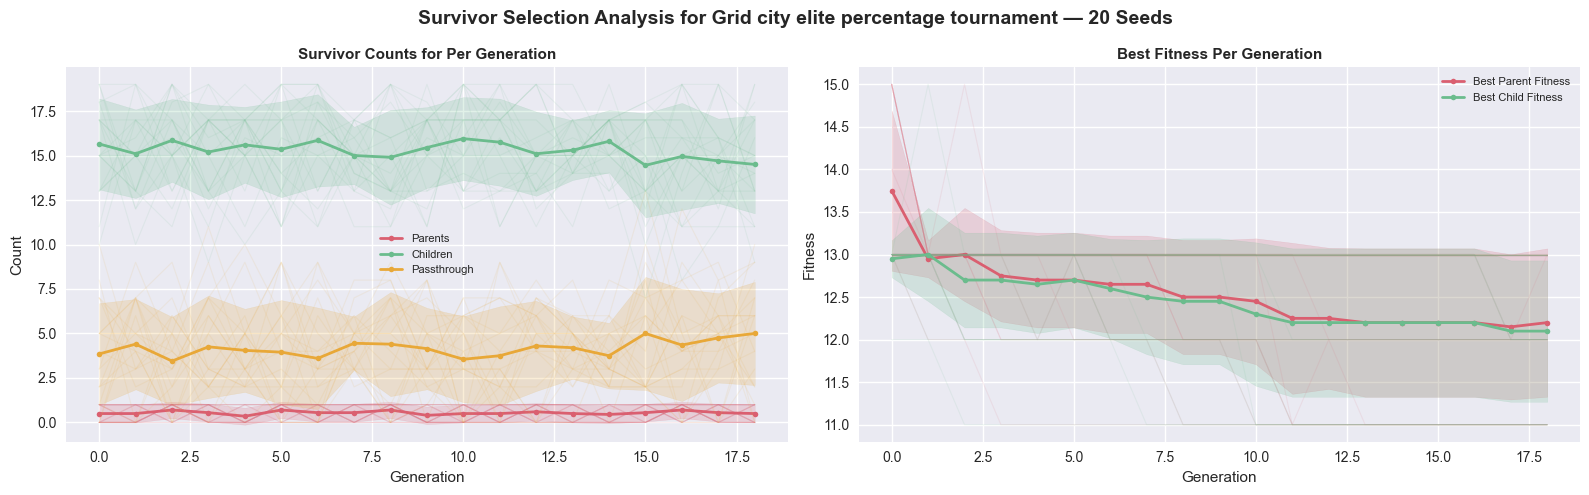

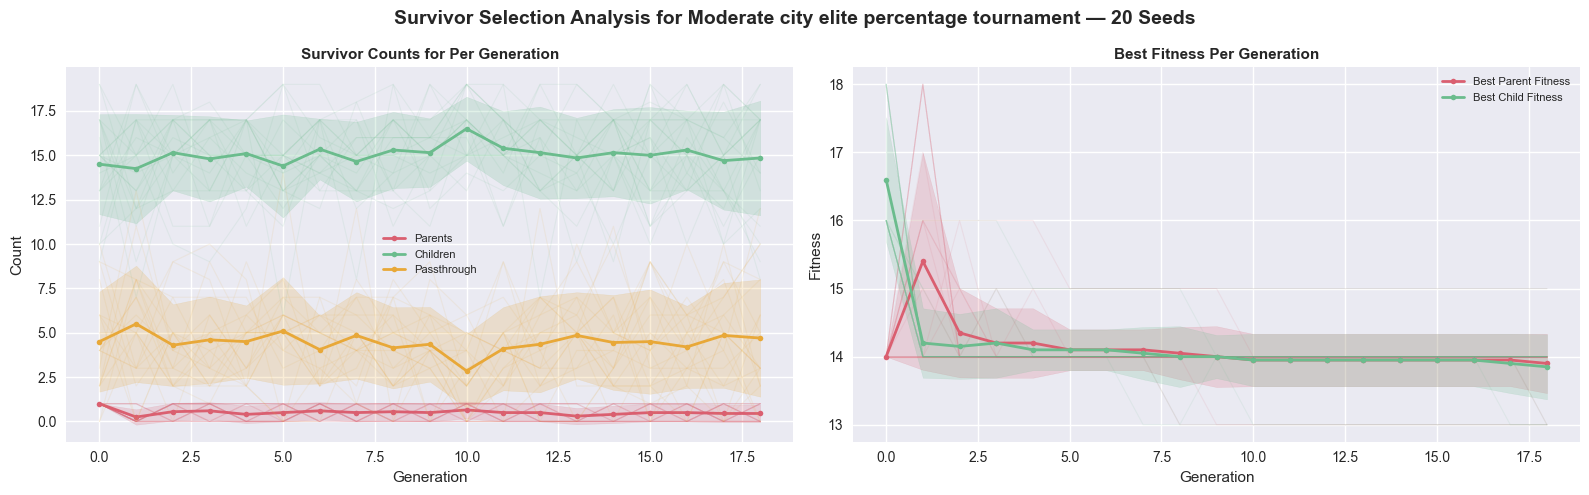

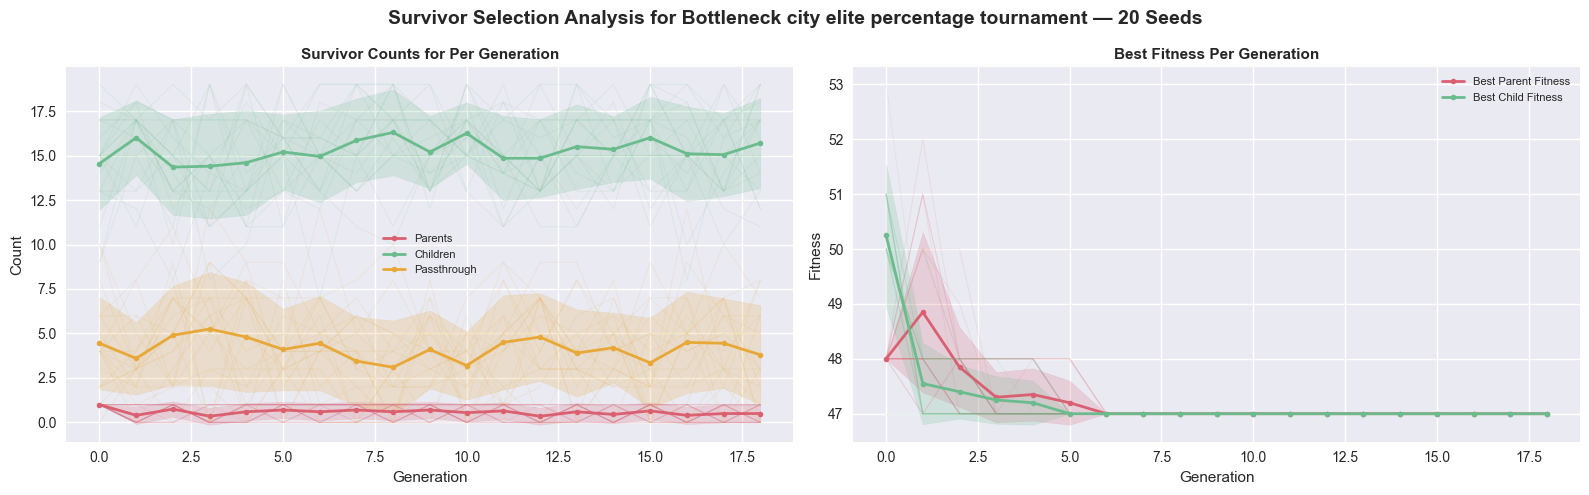

In [15]:
plot_survivor_selection(stats_grid_tournament, 'grid_city_elite_percentage_tournament')
plot_survivor_selection(stats_moderate_tournament, 'moderate_city_elite_percentage_tournament')
plot_survivor_selection(stats_bottleneck_tournament, 'bottleneck_city_elite_percentage_tournament')

#### **Conclusion / Next Steps**
* Using only children results in poor solutions (this can be investigated in later tuning steps to see if any improvement can be seen).
* Elite selections seems the best approach however we can also run at higher percetanges later to test if this helps (but do this after parameter tuning).

* The tournament selection approach is also converging prematurely so will stick with roulette for further investigation into hyper parameters.

### Convergence Criteria
* Adding in the fitness plateau
* Run lots of evolutions and map the critieria across time.
* Make sure to do this across all cities.
* Add in the time tracking to monitor across this as well.

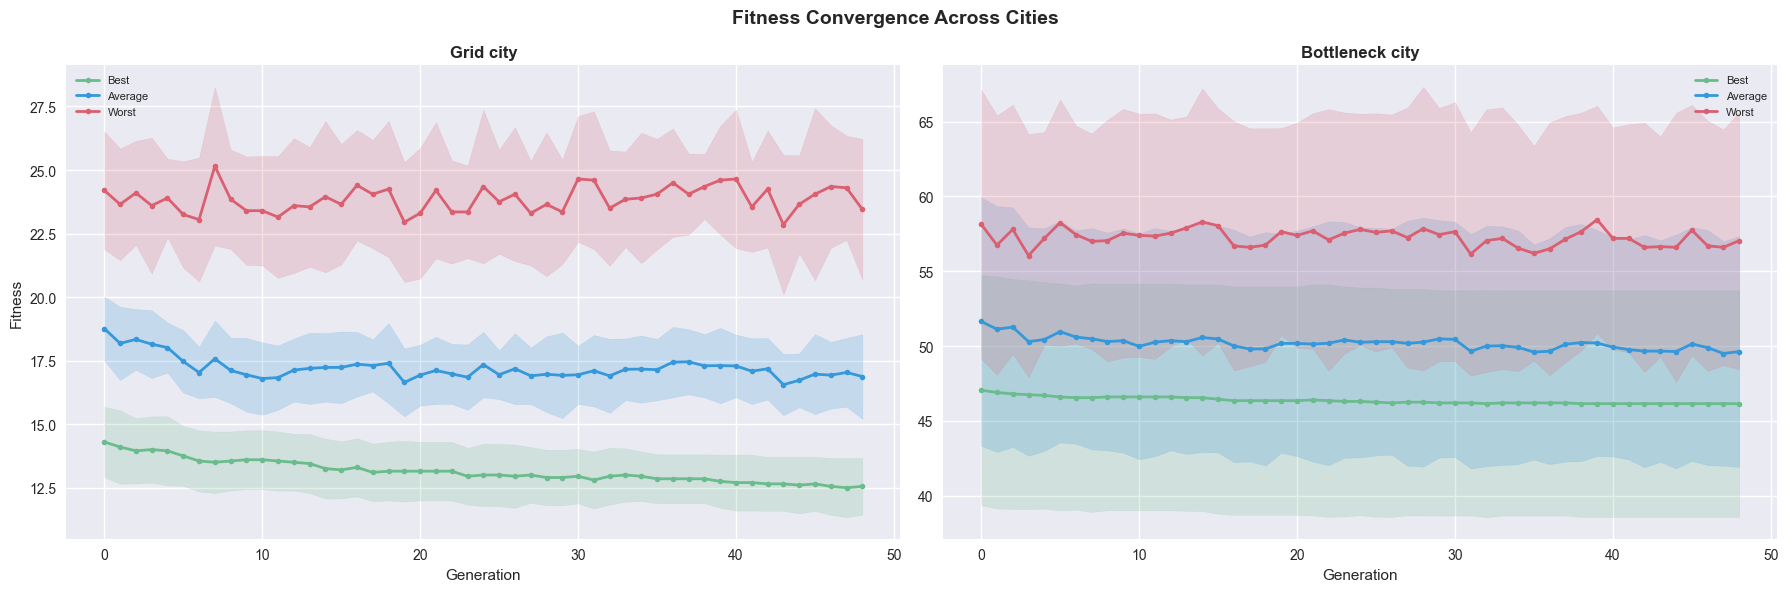

In [36]:
plot_covergence({
    'grid_city': stats_grid,
    # 'moderate_city': stats_moderate,
    'bottleneck_city': stats_bottleneck,
})

The green line (best) shows that the best soluton is slowly decreasing over time but this is a slow downward trend. The average trend is consistent across the generations which is concerning as the population as a whole is not improving which is supported by the fact the worst chromosome is also getting worse or fluctuating. These could indicate a lack of convergence.

`Conclusion`
Need to tune the parameters to see if the overall population fitness improves/converges.

#### Quick check for tournament...

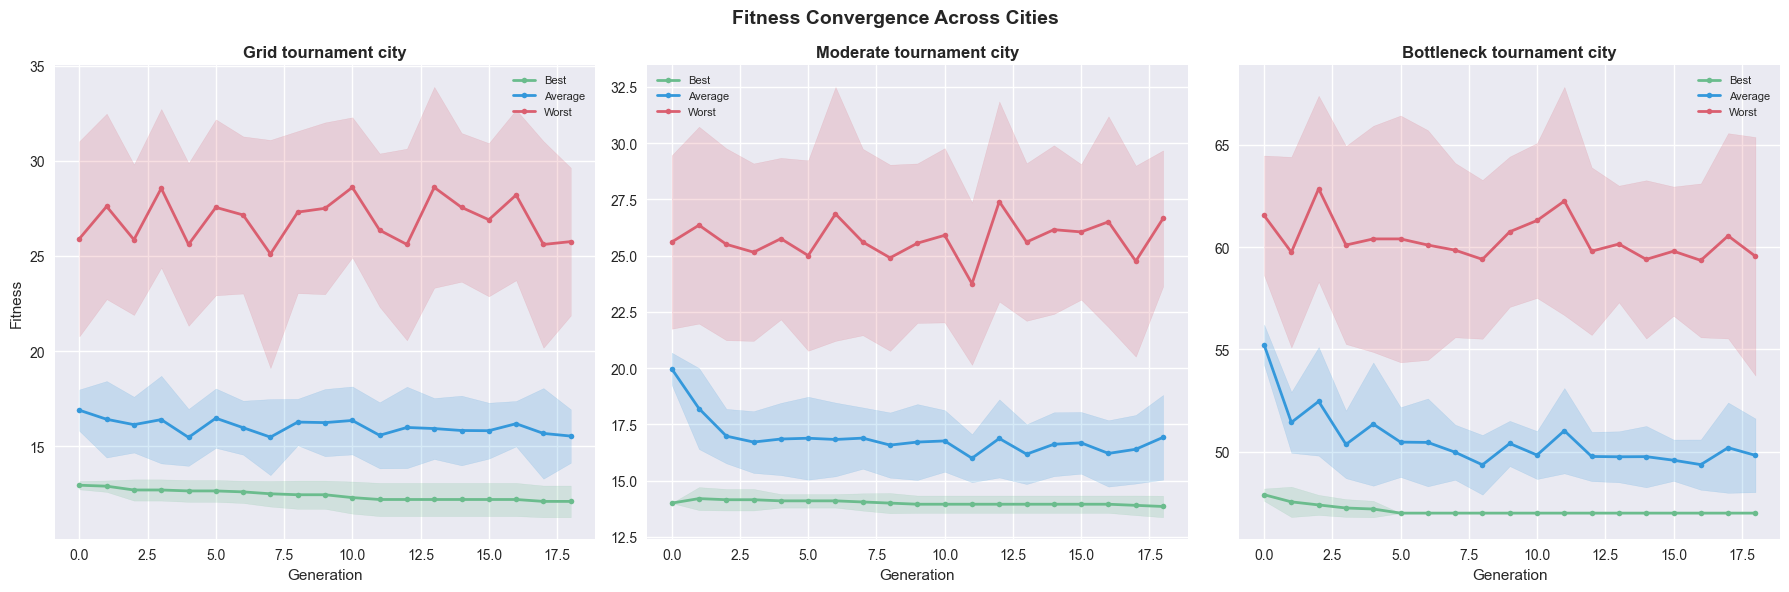

In [17]:
plot_covergence({
    'grid_tournament_city': stats_grid_tournament,
    'moderate_tournament_city': stats_moderate_tournament,
    'bottleneck_tournament_city': stats_bottleneck_tournament,
})

##### TODO: need to think about time and how increase the number of evolutions improves the final value.

In [ ]:
solution_grid, stats_grid, time_grid = extract_results('grid_city_50_experiments_analysis')
solution_moderate, stats_moderate, time_moderate = extract_results('moderate_city_20_survivor_selection_elite_percentage_experiments_analysis')
solution_bottleneck, stats_bottleneck, time_bottleneck = extract_results('bottleneck_city_20_survivor_selection_elite_percentage_experiments_analysis')

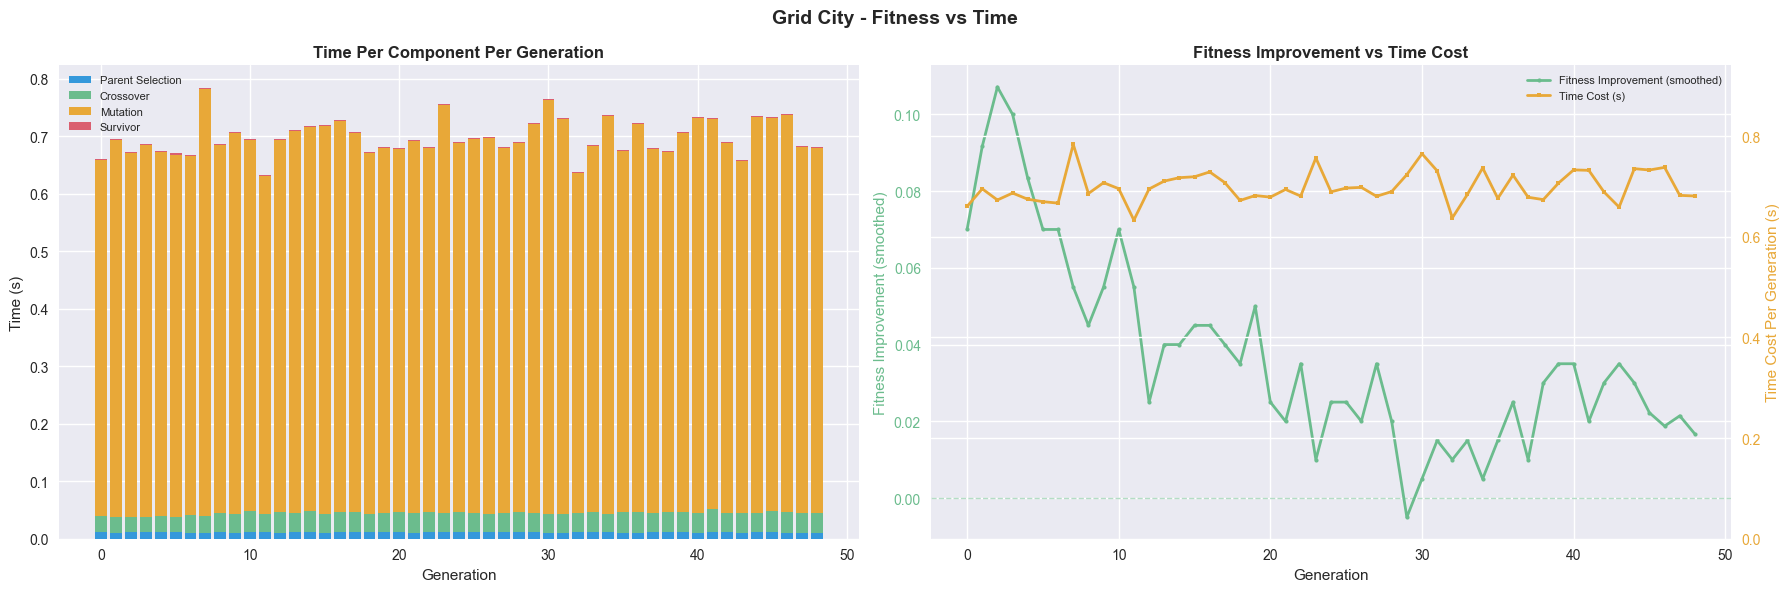

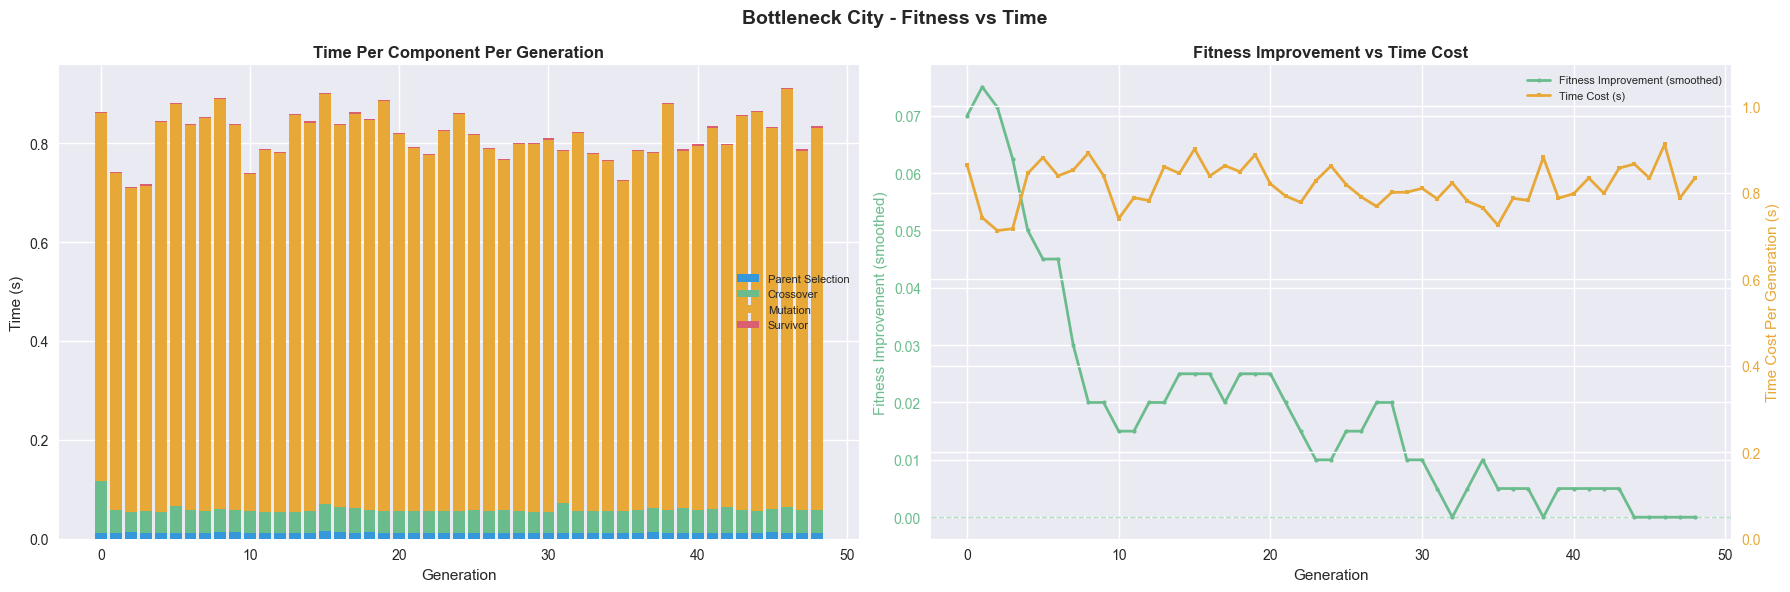

In [37]:
plot_fitness_vs_time(stats_grid, time_grid, 'Grid City - Fitness vs Time')
# plot_fitness_vs_time(stats_moderate, time_moderate, 'Moderate City - Fitness vs Time')
plot_fitness_vs_time(stats_bottleneck, time_bottleneck, 'Bottleneck City - Fitness vs Time')

### Parameter Tuning
Do all of the below for all the cities:
* Crossover probability threshold: `[0, 0.2, 0.4, 0.6, 0.8, 1]` - see how the congestion and path lenghts vary.
* Mutation probability threshold: `[0, 0.2, 0.4, 0.6, 0.8, 1]` - see how the congestion and path lenghts vary (especially important for bottleneck).
* Population Size: `[1, 5, 10, 20, 50, 100]` - showing congestion values vs runtime.
* Random Seed - run a large amount of results to show they are similar (and not seed sensitive).
* Epsilon: `[0, 0.2, 0.4, 0.6, 0.8, 1]` - try different values looking at congestion score performance, convergence speed and variance across seeds.
